In [134]:
import itertools as itt
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from common import FEATURES_OUTFILE
from dmm.initialisation import get_features, pca_transform_features
from sklearn.decomposition import PCA, SparsePCA
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression, MultiTaskElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [61]:
# Set up some hyperparams
samples = "0of5"
target_context = "cytof_dynamic"

# Need tuning -- number of pca components to keep in target + to keep in input
num_pca_target = 2  
num_pca_input = 0.95  # keep 95% of variance

input_context = "cytof_init"

In [62]:
def get_pca_features(samples: str, num_components: int, context: str, scale: bool = False, impute: bool = False, whiten: bool = True): 
    # Set up minimal conf
    target_conf_dict = {
        "model": "EGFR_MAPK",
        "data": "dream_cytof", 
        "samples": samples, 
        "features": "all", 
        "context": context,  # fixed target context
    }
    
    # Define filepath for features file
    features_filepath = FEATURES_OUTFILE.format(
        **{**target_conf_dict, **dict(dataset = "{dataset}")}
    )
    
    features = get_features(features_filepath=features_filepath, datasets=["train", "val"])
    
    steps = []
    if scale: 
        steps.append(('scale', StandardScaler(with_std=False)))
    if impute: 
        steps.append(('impute', KNNImputer()))
    steps.append(
        ('pca', PCA(
            n_components=num_components,  # keep all
            whiten=whiten, 
        ))
    )
    
    pipeline = Pipeline(steps)
    
    # fit on training features
    pipeline.fit(features["train"])
    
    # transform both train and val and return
    transformed_features = {
        dataset: pd.DataFrame(
            pipeline.transform(features[dataset]),
            index=features[dataset].index,
            columns=[f'pca_{i}' for i in range(pipeline.named_steps['pca'].n_components_)]
        )
        for dataset in features.keys()
    }
    return transformed_features, pipeline.named_steps['pca'].n_components_

In [63]:
def rmse(data: np.ndarray, pred: np.ndarray) -> float: 
    return np.sqrt(np.mean(np.square(data - pred)))

In [64]:
targets, _ = get_pca_features(samples, num_pca_target, context=target_context)  # dict with keys "train" and "val"

In [65]:
inputs, _ = get_pca_features(samples, num_pca_input, context=input_context, impute=True)  # missing features (NaNs) -> impute

In [66]:
# Experiment 1: simple LinearRegression
lr = LinearRegression()
lr.fit(inputs["train"], targets["train"])

rmse(targets["val"], lr.predict(inputs["val"]))

1.2457171727698233

In [127]:
def linreg_experiment(input_context: str, num_pca_input, target_context: str, num_pca_target): 
    # Get input features - handle imputation
    try:
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context)
    except ValueError: 
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context, impute=True)
    
    # Get target features
    targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context)
    
    # print("Features extracted")
    # 
    # Instantiate linear regressor and fit
    lr = LinearRegression()
    lr.fit(inputs["train"], targets["train"])
    
    # Compute RMSEs
    rmse_train, rmse_val = [
        rmse(targets[dataset], lr.predict(inputs[dataset]))
        for dataset in ["train", "val"]
    ]
    # print(f'RMSE train: {rmse_train}, RMSE validation: {rmse_val}')
    # print("RMSE computed")
    return (rmse_train, rmse_val), (pca_components_input, pca_components_target)

In [132]:
def elasticnet_experiment(input_context: str, num_pca_input, target_context: str, num_pca_target): 
    # Get input features - handle imputation
    try:
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context)
    except ValueError: 
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context, impute=True)
    
    # Get target features
    targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context)
    
    # print("Features extracted")
    # 
    # Instantiate linear regressor and fit
    regressor = MultiTaskElasticNetCV()
    regressor.fit(inputs["train"], targets["train"])
    
    # Compute RMSEs
    rmse_train, rmse_val = [
        rmse(targets[dataset], regressor.predict(inputs[dataset]))
        for dataset in ["train", "val"]
    ]
    # print(f'RMSE train: {rmse_train}, RMSE validation: {rmse_val}')
    # print("RMSE computed")
    return (rmse_train, rmse_val), (pca_components_input, pca_components_target)

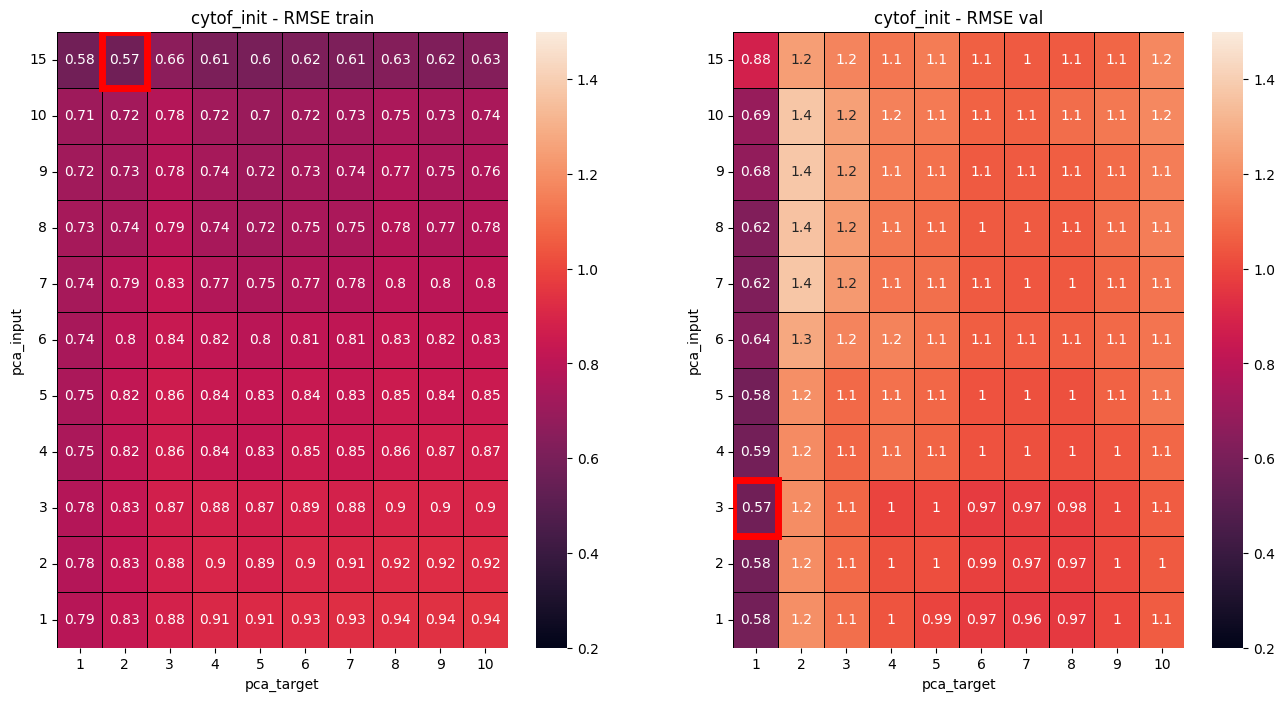

KeyboardInterrupt: 

In [135]:
for input_context in ["cytof_init", "proteomics", "transcriptomics"]:
    results = {"train": {}, "val": {}}
    for num_pca_input, num_pca_target in itt.product(
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
    ): 
        (rmse_train, rmse_val), (pca_input, pca_target) = linreg_experiment(input_context, num_pca_input, target_context, num_pca_target)
        results["train"][(pca_input, pca_target)] = rmse_train
        results["val"][(pca_input, pca_target)] = rmse_val
    
    norm = mcolors.Normalize(vmin=0.2, vmax=1.5) 
    # Create the heatmap
    plt.subplots(1, 2, figsize=(16, 8))
    for ind, dataset in enumerate(results.keys()):
        # Convert the results dictionary into a pandas DataFrame
        df = pd.DataFrame.from_dict(results[dataset], orient='index', columns=['RMSE'])
        df.index = pd.MultiIndex.from_tuples(df.index, names=['pca_input', 'pca_target'])
        
        # Reset index to turn the index into columns if needed
        df = df.reset_index()
        # pivot the dataframe
        pivot_df = df.pivot(index='pca_input', columns='pca_target', values='RMSE')
        
        plt.subplot(1, 2, ind+1)
        ax = plt.gca()
        ax = sns.heatmap(pivot_df, linewidths=0.5, linecolor='black', annot=True, cbar=True, norm=norm)
        ax.invert_yaxis()
        # Find the location of the minimum value
        min_value = pivot_df.min().min()
        min_location = np.where(pivot_df == min_value)
        
        plt.yticks(rotation=0)
        
        # Draw a rectangle around the cell with the minimum value
        for y, x in zip(*min_location):
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=5))
        ax.set_title(f'{input_context} - RMSE {dataset}')
    plt.savefig(f'linreg_{input_context}_{target_context}_PCA.png')
    plt.show()

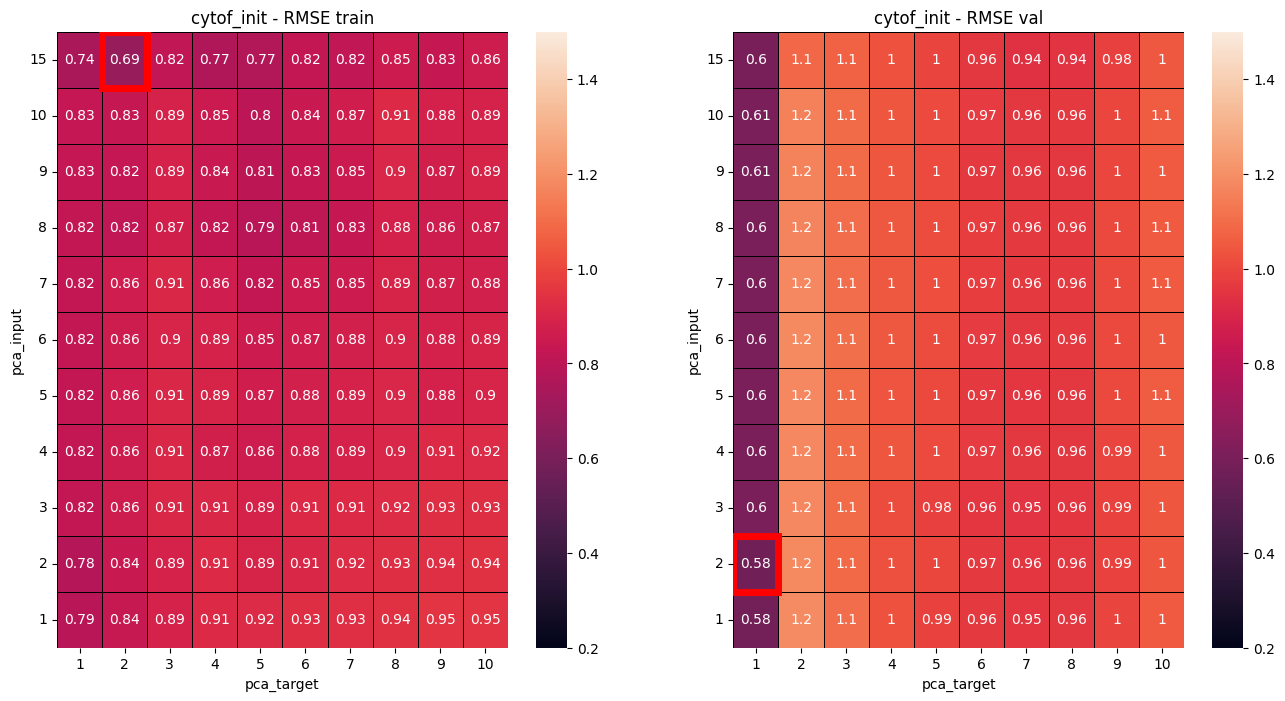

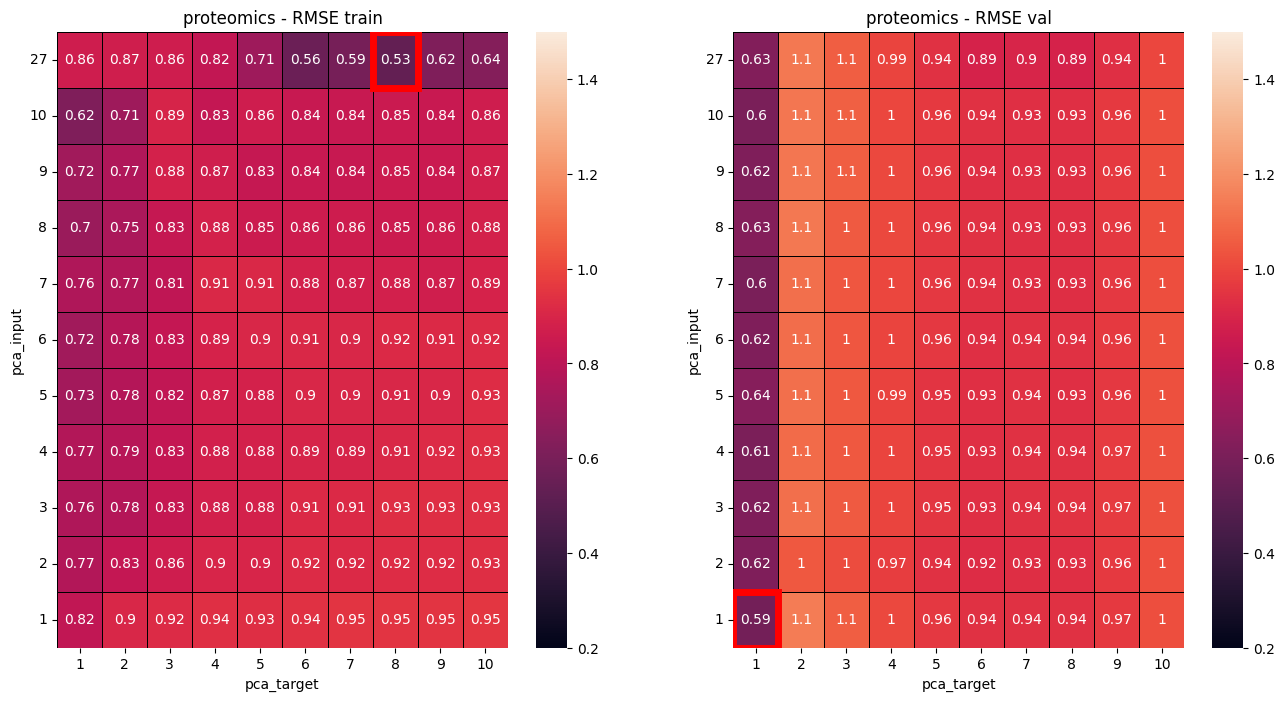

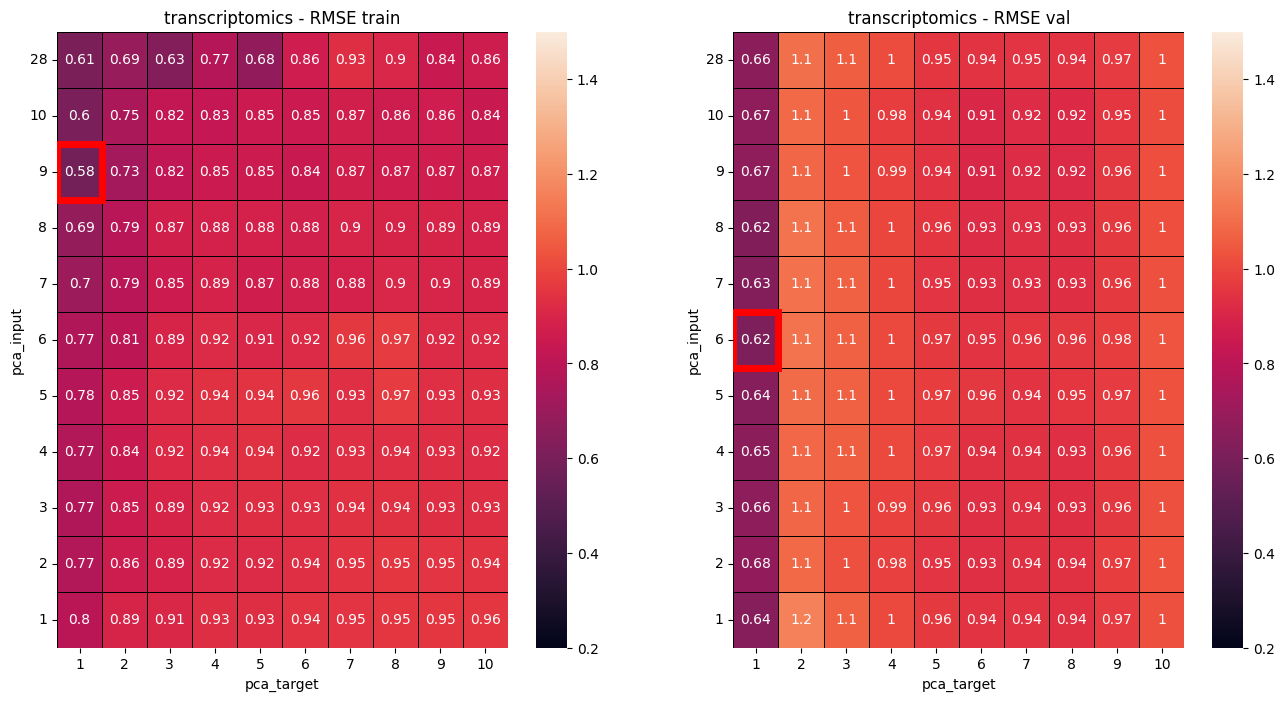

In [136]:
for input_context in ["cytof_init", "proteomics", "transcriptomics"]:
    results = {"train": {}, "val": {}}
    for num_pca_input, num_pca_target in itt.product(
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0.95], 
    ): 
        (rmse_train, rmse_val), (pca_input, pca_target) = elasticnet_experiment(input_context, num_pca_input, target_context, num_pca_target)
        results["train"][(pca_input, pca_target)] = rmse_train
        results["val"][(pca_input, pca_target)] = rmse_val
    
    norm = mcolors.Normalize(vmin=0.2, vmax=1.5) 
    # Create the heatmap
    plt.subplots(1, 2, figsize=(16, 8))
    for ind, dataset in enumerate(results.keys()):
        # Convert the results dictionary into a pandas DataFrame
        df = pd.DataFrame.from_dict(results[dataset], orient='index', columns=['RMSE'])
        df.index = pd.MultiIndex.from_tuples(df.index, names=['pca_input', 'pca_target'])
        
        # Reset index to turn the index into columns if needed
        df = df.reset_index()
        # pivot the dataframe
        pivot_df = df.pivot(index='pca_input', columns='pca_target', values='RMSE')
        
        plt.subplot(1, 2, ind+1)
        ax = plt.gca()
        ax = sns.heatmap(pivot_df, linewidths=0.5, linecolor='black', annot=True, cbar=True, norm=norm)
        ax.invert_yaxis()
        # Find the location of the minimum value
        min_value = pivot_df.min().min()
        min_location = np.where(pivot_df == min_value)
        
        plt.yticks(rotation=0)
        
        # Draw a rectangle around the cell with the minimum value
        for y, x in zip(*min_location):
            ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor='red', lw=5))
        ax.set_title(f'{input_context} - RMSE {dataset}')
    plt.savefig(f'MTelasticnet_{input_context}_{target_context}_PCA.png')
    plt.show()

In [265]:
import equinox as eqx
import jax.numpy as jnp
import jax.random as jr
import optax
import tqdm

from jax.nn import tanh, relu, swish
from jax import vmap


def train_MLP(
        input_context: str, num_pca_input, 
        target_context: str, num_pca_target, 
        depth: int, width: int, activation_fn_name: str, 
        l1reg_scale: float=0, 
        lr: float = 1e-3, weight_decay: float = 1e-4,
        num_epochs: int = 1000,
): 
    # Get input features - handle imputation
    try:
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context)
    except ValueError: 
        inputs, pca_components_input = get_pca_features(samples, num_pca_input, context=input_context, impute=True)
    
    # Get target features
    targets, pca_components_target = get_pca_features(samples, num_pca_target, context=target_context)
    
    # Compute input/output sizes for MLP
    input_size = pca_components_input
    output_size = pca_components_target
    
    # Define activation functions
    activations = {
        "relu": relu, 
        "swish": swish, 
        "tanh": tanh, 
    }
    
    # create MLP instance (default initialisation)
    mlp = eqx.nn.MLP(
        in_size=input_size, 
        out_size=output_size, 
        width_size=width, 
        depth=depth, 
        activation=activations[activation_fn_name], 
        key=jr.PRNGKey(0),
    )
    
    # Define optimizer
    opt = optax.adamw(learning_rate=lr, weight_decay=weight_decay)
    # Get diff and static
    diff_model, static_model = eqx.partition(mlp, eqx.is_array)
    # Initialise optimizer state
    opt_state = opt.init(diff_model)
    
    @eqx.filter_jit
    def jax_rmse(data: jnp.ndarray, pred: jnp.ndarray) -> float: 
        return jnp.sqrt(jnp.mean(jnp.square(data - pred)))
    
    @eqx.filter_jit
    def MLP_loss(diff_model, static_model, input_data, target_data):
        model = eqx.combine(diff_model, static_model)
        return jax_rmse(target_data, vmap(model)(input_data))
    
    def l1reg(model): 
        reg = 0
        for layer in model.layers: 
            reg += jnp.mean(jnp.abs(layer.weight))
        return reg/len(model.layers)
    
    @eqx.filter_value_and_grad
    def MLP_loss_and_grad(diff_model, static_model, input_data, target_data, l1reg_scale=0):
        model = eqx.combine(diff_model, static_model)
        return jax_rmse(target_data, vmap(model)(input_data)) + l1reg_scale*l1reg(model)
    
    @eqx.filter_jit
    def make_MLP_step(diff_model, static_model, opt, opt_state, input_data, target_data):
        loss, grads = MLP_loss_and_grad(
            diff_model, 
            static_model,
            input_data,
            target_data, 
            l1reg_scale, 
        )
        updates, opt_state = opt.update(grads, opt_state, diff_model)
        # Update model in `next_model`, but keep current one in `model` for current epoch metric logging
        diff_model = eqx.apply_updates(diff_model, updates)
        return diff_model, static_model, opt_state, loss, grads
    
    loss_train_history, loss_val_history = [], []
    
    # Train the model
    for epoch in tqdm.tqdm(range(num_epochs)): 
        diff_model, static_model, opt_state, loss, grads = make_MLP_step(
            diff_model, static_model, 
            opt, opt_state, 
            inputs["train"].values, targets["train"].values
        )
        loss_train_history.append(loss)
        
        if epoch % 25 == 0: 
            loss_val = MLP_loss(diff_model, static_model, inputs["val"].values, targets["val"].values)
            loss_val_history.append(loss_val)
            # print(f'Epoch {epoch} - Training Loss: {loss} - Validation Loss: {loss_val}')
            
    return eqx.combine(diff_model, static_model), loss_train_history, loss_val_history
    

100%|██████████| 4000/4000 [00:01<00:00, 2594.26it/s]


Text(0.5, 1.0, 'cytof_init -> cytof_dynamic')

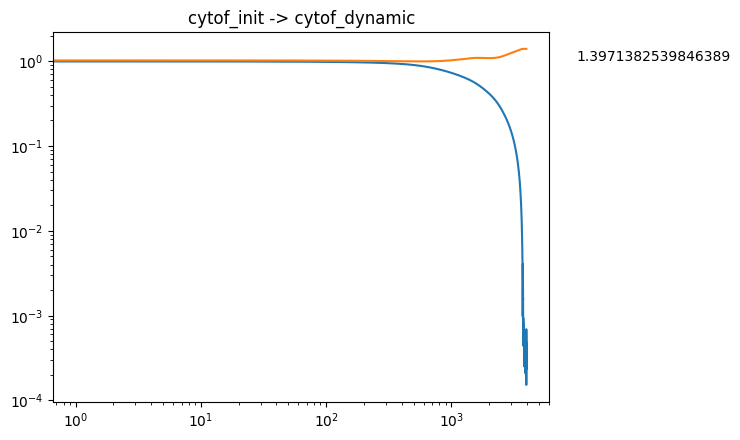

In [235]:
model, loss_train_history, loss_val_history = train_MLP(
    input_context="cytof_init", num_pca_input=0.95, 
    target_context="cytof_dynamic", num_pca_target=0.95, 
    depth=2, width=20, activation_fn_name="swish", 
    l1reg_scale=0, 
    lr=1e-4, num_epochs=4000
)

plt.plot(np.arange(0, 4000), loss_train_history)
plt.plot(np.arange(0, 4000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("cytof_init -> cytof_dynamic")

100%|██████████| 4000/4000 [00:01<00:00, 2416.67it/s]


Text(0.5, 1.0, 'proteomics -> cytof_dynamic')

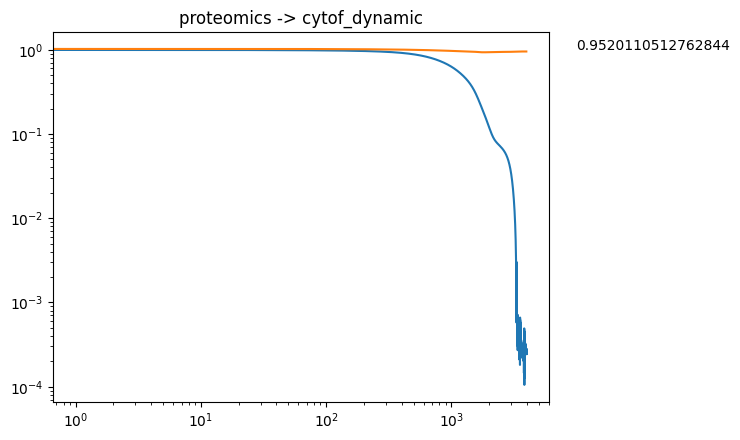

In [238]:
model, loss_train_history, loss_val_history = train_MLP(
    input_context="proteomics", num_pca_input=0.95,
    target_context="cytof_dynamic", num_pca_target=0.95,
    depth=2, width=20, activation_fn_name="swish",
    l1reg_scale=0, 
    lr=1e-4, num_epochs=4000
)

plt.plot(np.arange(0, 4000), loss_train_history)
plt.plot(np.arange(0, 4000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("proteomics -> cytof_dynamic")

100%|██████████| 4000/4000 [00:01<00:00, 2504.16it/s]


Text(0.5, 1.0, 'transcriptomics -> cytof_dynamic')

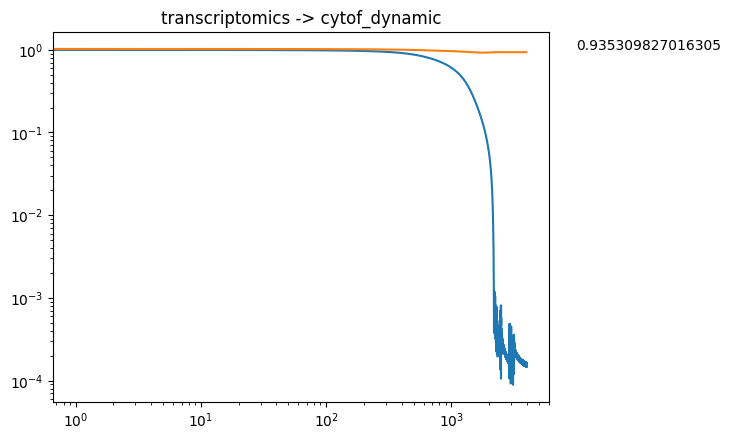

In [247]:
model, loss_train_history, loss_val_history = train_MLP(
    input_context="transcriptomics", num_pca_input=0.95,
    target_context="cytof_dynamic", num_pca_target=0.95,
    depth=2, width=20, activation_fn_name="swish",
    l1reg_scale=0,
    lr=1e-4, num_epochs=4000
)

plt.plot(np.arange(0, 4000), loss_train_history)
plt.plot(np.arange(0, 4000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("transcriptomics -> cytof_dynamic")

100%|██████████| 8000/8000 [00:01<00:00, 4588.00it/s]


Text(0.5, 1.0, 'cytof_dynamic -> cytof_dynamic')

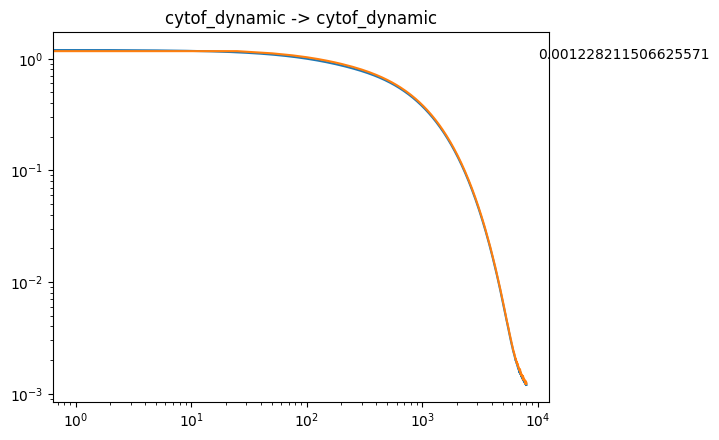

In [294]:
# Last resort: cytof_dynamic -> cytof_dynamic -- can only learn an identity mapping through heavy regularisation + no depth (single linear layer, no activation function)
model, loss_train_history, loss_val_history = train_MLP(
    input_context="cytof_dynamic", num_pca_input=0.95,
    target_context="cytof_dynamic", num_pca_target=0.95,
    depth=0, width=10, activation_fn_name="swish",
    l1reg_scale=0,
    lr=1e-3, weight_decay=1, 
    num_epochs=8000
)

plt.plot(np.arange(0, 8000), loss_train_history)
plt.plot(np.arange(0, 8000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("cytof_dynamic -> cytof_dynamic")

100%|██████████| 8000/8000 [00:01<00:00, 4614.23it/s]


Text(0.5, 1.0, 'cytof_init -> cytof_dynamic')

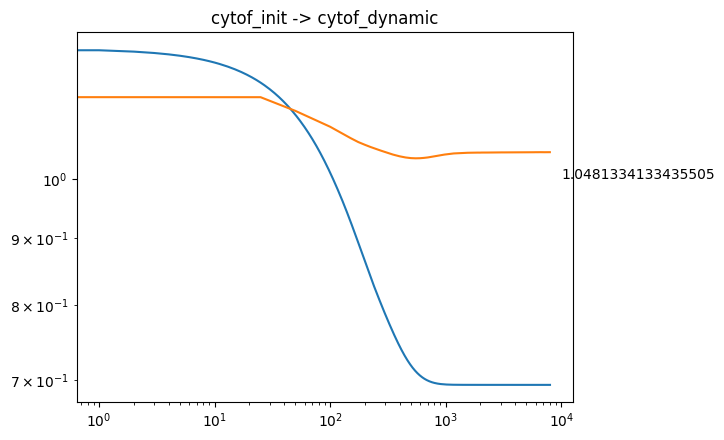

In [312]:
model, loss_train_history, loss_val_history = train_MLP(
    input_context="cytof_init", num_pca_input=0.95,
    target_context="cytof_dynamic", num_pca_target=0.95,
    depth=0, width=10, activation_fn_name="swish",
    l1reg_scale=0.5,
    lr=1e-3, weight_decay=0.1, 
    num_epochs=8000
)

plt.plot(np.arange(0, 8000), loss_train_history)
plt.plot(np.arange(0, 8000, 25), loss_val_history)
plt.text(10000, 1, loss_val_history[-1])
plt.xscale('log')
plt.yscale('log')
plt.title("cytof_init -> cytof_dynamic")

100%|██████████| 4000/4000 [00:00<00:00, 4501.93it/s]


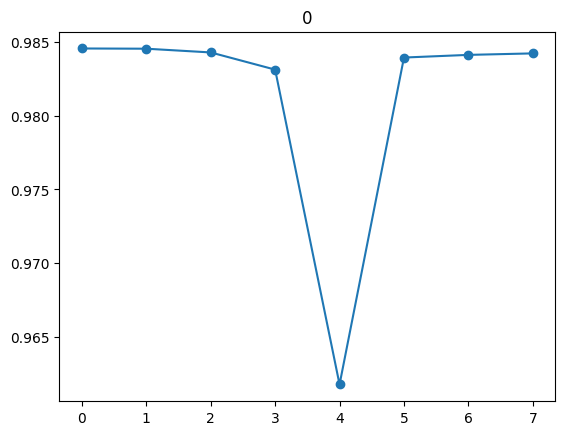

100%|██████████| 4000/4000 [00:01<00:00, 3345.03it/s]


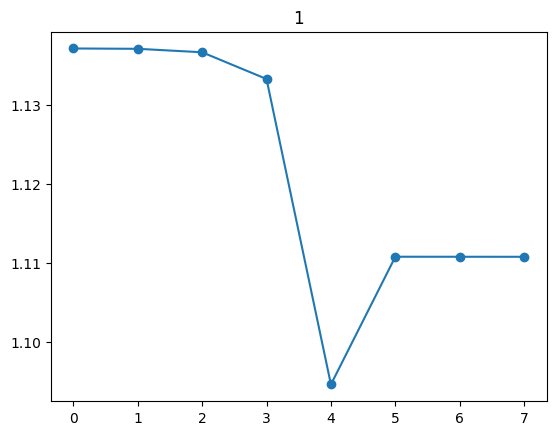

100%|██████████| 4000/4000 [00:01<00:00, 2678.36it/s]


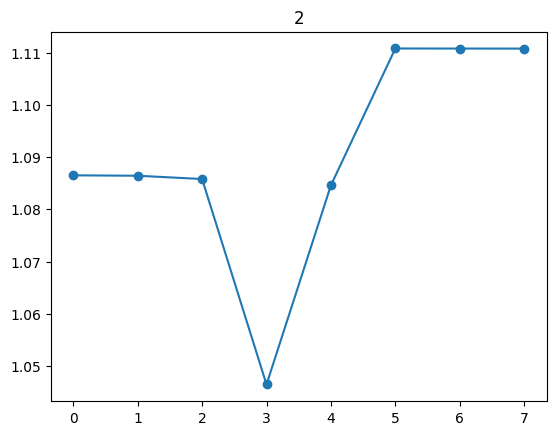

In [332]:
for depth in [0, 1, 2]: 
    results = []
    for l1reg_scale in  [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]: 
        _, _, loss_val_history = train_MLP(
            input_context="cytof_init", num_pca_input=0.95,
            target_context="cytof_dynamic", num_pca_target=3,
            depth=depth, width=10, activation_fn_name="swish",
            l1reg_scale=l1reg_scale,
            lr=1e-3, weight_decay=1e-2, 
            num_epochs=4000
        )
        min_loss = np.min(loss_val_history)
        results.append(min_loss)
    plt.plot(results, marker='o')
    plt.title(depth)
    plt.show()

In [323]:
# Assuming your dictionary is named 'results'
min_key = min(results, key=results.get)

In [324]:
min_key

(1, 0.01, 0.01)

In [325]:
results[(1, 1, 0.01)]

1.1861128004735997